In [ ]:
# Para tratamiento de datos
import polars as pl
import math
# Para visualizaciones
import seaborn as sns 
import matplotlib.pyplot as plt
# Para gestión de fechas
from datetime import datetime
# Para conectar a la base de datos
import psycopg2
# Cargar variables de entorno
import os
import sys
from dotenv import load_dotenv
# Configuracion de Polars para mostrar todas las columnas y hasta 25 filas
pl.Config.set_tbl_rows(25)  # Asegura que se muestren hasta 1000 filas
pl.Config.set_tbl_width_chars(500)  # Aumenta el ancho para evitar cortes
# Configuracion para importar src
current_working_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_working_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
# importamos funciones de soporte
from src import funciones_load as fl
from src import funciones_eda as feda

In [2]:
conexion = os.getenv("conexion_bbdd")
madrid_22 = feda.obtener_datos_madrid(conexion, 2022, 2022, "Madrid")

Conexión establecida y consulta de prueba exitosa.


In [3]:
df_mensual, estaciones, contaminantes = feda.preproceso_datos(madrid_22)

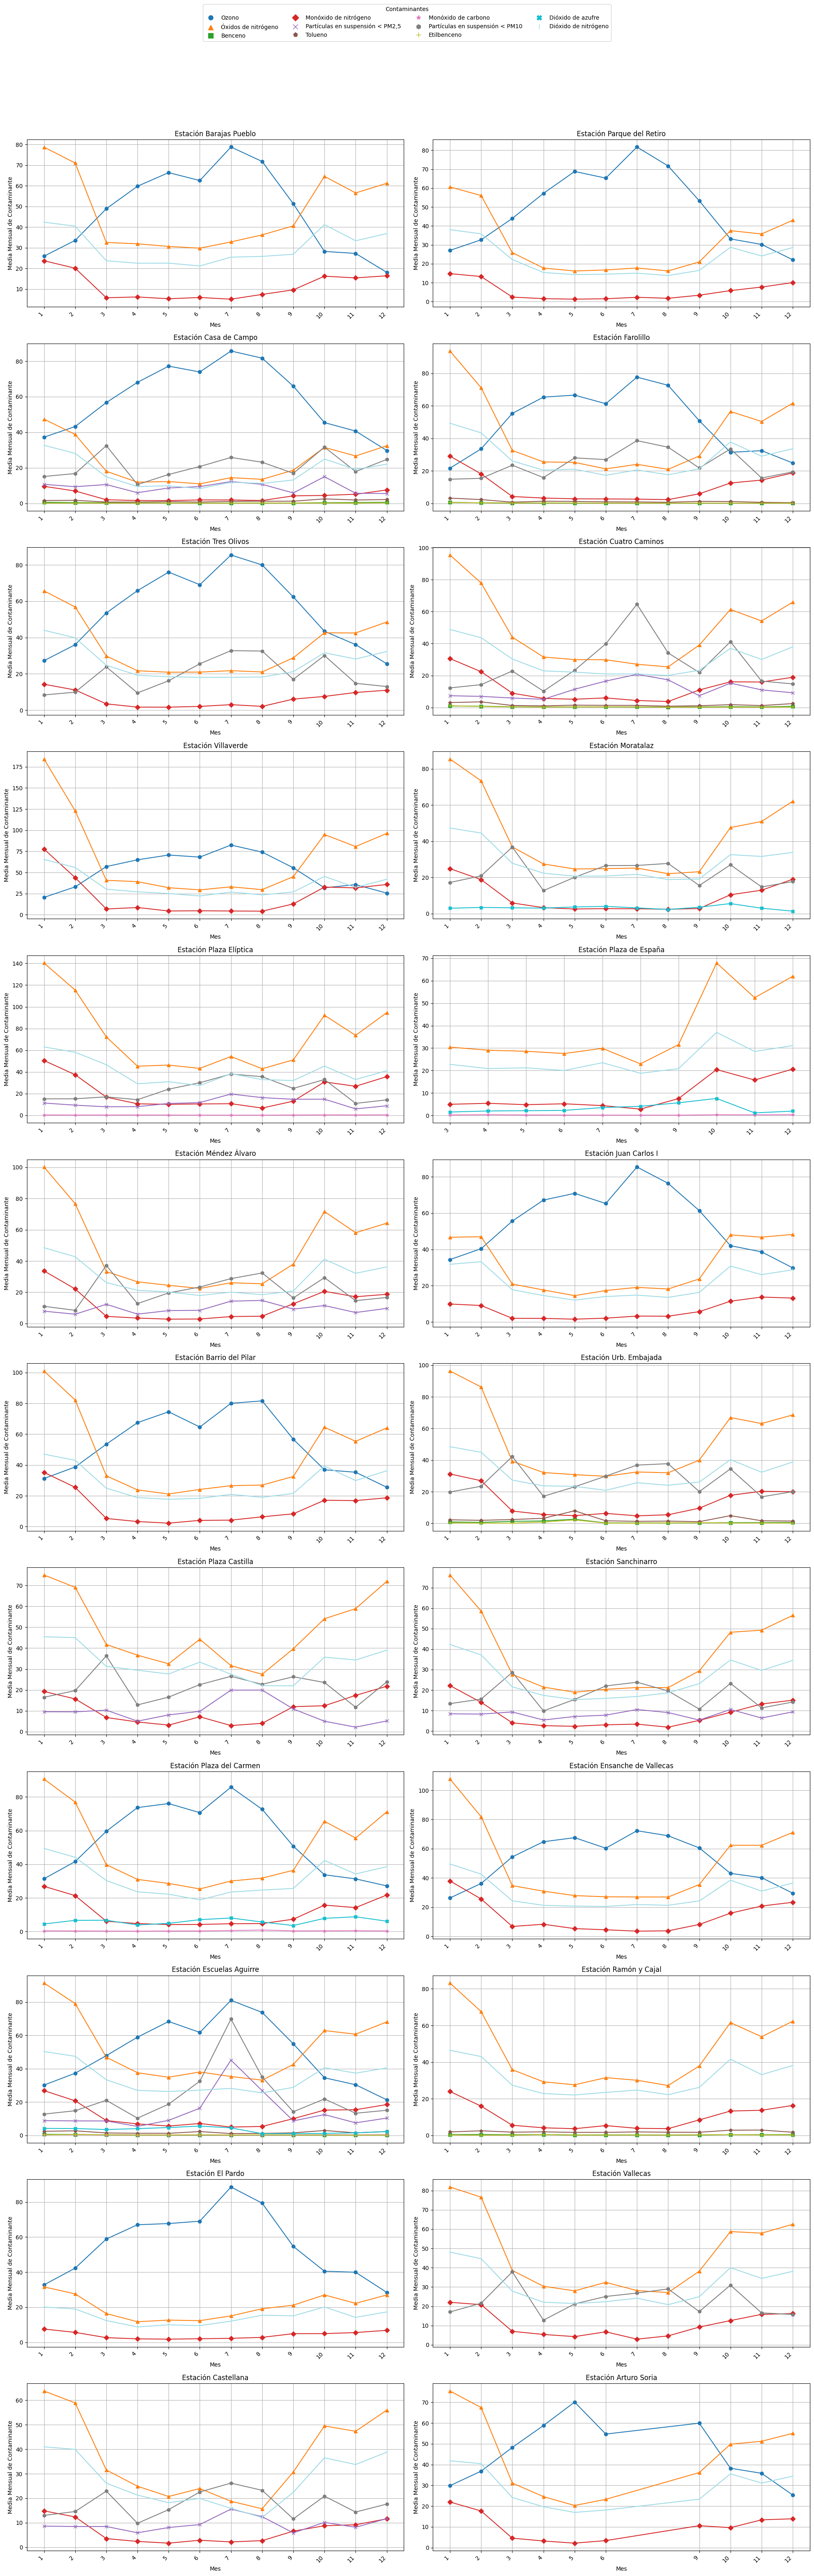

In [4]:
feda.graficos_estaciones(df_mensual, estaciones, contaminantes)

Analizamos los contaminantes que se miden en más estaciones, ya que son los que permiten mejor comparación entre ellas.

In [5]:
contaminantes_por_estacion = (
    madrid_22.group_by("contaminante")
    .agg(pl.col("estacion").n_unique().alias("num_estaciones"))
    .sort("num_estaciones", descending=True)  # Opcional, para ordenar de mayor a menor
)
contaminantes_por_estacion

contaminante,num_estaciones
str,u32
"""Dióxido de nitrógeno""",24
"""Monóxido de nitrógeno""",24
"""Óxidos de nitrógeno""",24
"""Partículas en suspensión < PM1…",13
"""Ozono""",13
"""Partículas en suspensión < PM2…",8
"""Etilbenceno""",6
"""Tolueno""",6
"""Benceno""",6


Mientras que los  **Óxidos de nitrógeno** siguen un patrón muy similar en todas las estaciones, y similares a los anteriores años, el **Ozono** este año presenta dos picos, en junio y en agosto, siendo más alto el de agosto, lo que lo diferencia de los años anteriores, en los que se mantenía más estable entre marzo y octubre.  
Este año presenta más valores altos de  **Partículas en suspensión < PM10**, especialmente en febrero y los meses de verano. 
El **monóxido de carbono** ha dejado de medirse en varias estaciones, igual que el **dióxido de azufre**, pasando a medirse en 4 de las 24 estaciones. 
Hay más estaciones que miden **Partículas en suspensión < PM2,5**
